# Tesla (TSLA) Stock Price Prediction
## Regression Analysis Assignment

**Dataset:** Tesla Stock Data (2010–2020) from Kaggle  
**Target Variable:** Daily Closing Price (`Close`)  
**Methods:** Multiple Linear Regression, Ridge Regression, Lasso Regression  

---

## Part 1 — Setup: Import Libraries

In [1]:
#Standard data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

#Scikit-learn: modelling, preprocessing, evaluation
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Stats models for OLS summary output
import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

# Global plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('All libraries imported successfully.')

All libraries imported successfully.


---
## Part 2 — Data Loading & Initial Inspection

In [2]:
#Load data
# If running in Google Colab, upload TSLA.csv using the file panel on the left,
# or mount your Google Drive and adjust the path accordingly.
df = pd.read_csv('TSLA.csv')

# Parse Date column as datetime and sort chronologically
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f'Dataset shape: {df.shape}')
print(f'Date range: {df["Date"].min().date()} to {df["Date"].max().date()}')
print(f'\nFirst 5 rows:')
df.head()

Dataset shape: (2416, 7)
Date range: 2010-06-29 to 2020-02-03

First 5 rows:


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [3]:
#Data types and null value check
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n✓ No missing values detected. Dataset is clean for analysis.')

=== Data Types ===
Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object

=== Missing Values ===
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

✓ No missing values detected. Dataset is clean for analysis.


In [4]:
#Descriptive statistics
df.describe().round(2)

,Date,Open,High,Low,Close,Adj Close,Volume
count,2416,2416.00,2416.00,2416.00,2416.00,2416.00,2416.00
mean,2015-04-15 11:09:56.026490112,186.27,189.58,182.92,186.40,186.40,5572721.69
min,2010-06-29 00:00:00,16.14,16.63,14.98,15.80,15.80,118500.00
25%,2012-11-19 18:00:00,34.34,34.90,33.59,34.40,34.40,1899275.00
50%,2015-04-16 12:00:00,213.04,216.75,208.87,212.96,212.96,4578400.00
75%,2017-09-07 06:00:00,266.45,270.93,262.10,266.77,266.77,7361150.00
max,2020-02-03 00:00:00,673.69,786.14,673.52,780.00,780.00,47065000.00
std,NaN,118.74,120.89,116.86,119.14,119.14,4987809.15


---
## Part 3 — Data Cleaning & Feature Engineering

The raw dataset contains Open, High, Low, Close, Volume columns.  
We engineer additional features to capture intraday volatility and momentum signals:
- `Price_Range` = High − Low (daily volatility proxy)
- `Avg_Price` = (High + Low) / 2 (intraday midpoint)
- `Prev_Close` = Close shifted by 1 day (yesterday's closing price as a predictor)
- `Daily_Return` = percentage change in Close (for EDA only)
- `Close_MA5`, `Close_MA20` = 5-day and 20-day moving averages (for EDA only)

`Adj Close` is dropped because it is nearly identical to `Close` in this dataset and would introduce perfect multicollinearity.

In [6]:
# ── Drop redundant column ─────────────────────────────────────────────────────
df = df.drop(columns=['Adj Close'])

# ── Engineer new features ─────────────────────────────────────────────────────
df['Price_Range']  = df['High'] - df['Low']          # Intraday price range
df['Avg_Price']    = (df['High'] + df['Low']) / 2    # Intraday midpoint
df['Prev_Close']   = df['Close'].shift(1)             # Lagged closing price
df['Daily_Return'] = df['Close'].pct_change()         # Daily return (EDA only)
df['Close_MA5']    = df['Close'].rolling(5).mean()    # 5-day moving average
df['Close_MA20']   = df['Close'].rolling(20).mean()   # 20-day moving average

# ── Remove NaN rows created by rolling/shift operations ───────────────────────
n_before = len(df)
df = df.dropna().reset_index(drop=True)
n_after = len(df)

print(f'Rows removed due to NaN (from lag/rolling): {n_before - n_after}')
print(f'Final dataset shape: {df.shape}')
df.head()

Rows removed due to NaN (from lag/rolling): 19
Final dataset shape: (2397, 12)


,Date,Open,High,Low,Close,Volume,Price_Range,Avg_Price,Prev_Close,Daily_Return,Close_MA5,Close_MA20
0,2010-07-27,20.910000,21.180000,20.260000,20.549999,619700,0.920000,20.720000,20.950001,-0.019093,20.802,19.8715
1,2010-07-28,20.549999,20.900000,20.510000,20.719999,467200,0.390000,20.705000,20.549999,0.008273,20.902,19.7130
2,2010-07-29,20.770000,20.879999,20.000000,20.350000,616000,0.879999,20.439999,20.719999,-0.017857,20.772,19.5390
3,2010-07-30,20.200001,20.440001,19.549999,19.940001,426900,0.890002,19.995000,20.350000,-0.020147,20.502,19.4380
4,2010-08-02,20.500000,20.969999,20.330000,20.920000,718100,0.639999,20.649999,19.940001,0.049147,20.496,19.5240


---
## Part 4 — Exploratory Data Analysis (EDA)

### 4.1 Closing Price Over Time

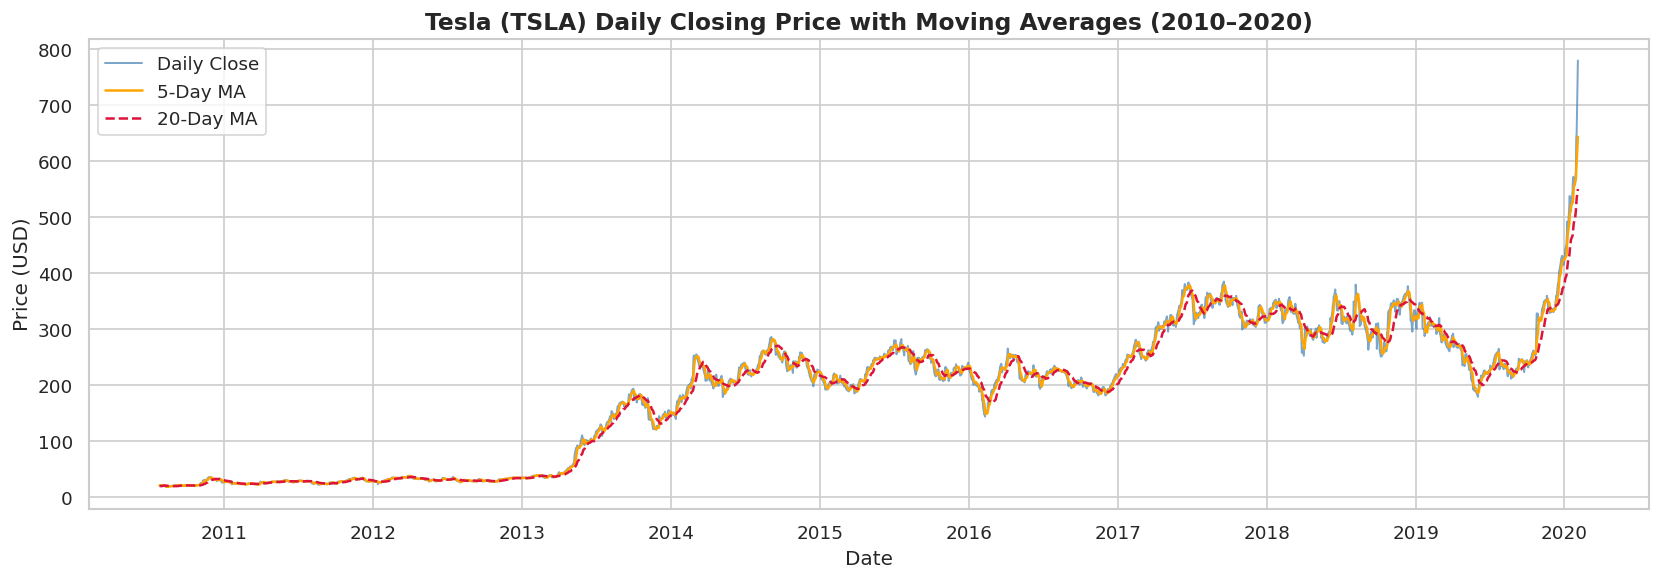


Interpretation: TSLA traded relatively flat below $50 from 2010 to mid-2013,
then experienced a rapid rise to ~$280 by 2014 before entering a consolidation
phase. A dramatic exponential surge began in late 2019, with the price reaching
$780 by February 2020. The MA5 closely tracks the daily price, while the MA20
smooths short-term noise and confirms the overall upward trend.



In [7]:
# ── Line chart: TSLA closing price with moving averages ───────────────────────
# Rationale: A time-series line chart is the most appropriate way to visualise
# a stock's price evolution. Overlaying MA5 and MA20 reveals short-term vs
# long-term momentum and highlights periods of high volatility (e.g., 2019–2020).

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df['Date'], df['Close'], color='steelblue', lw=1.2,
        alpha=0.7, label='Daily Close')
ax.plot(df['Date'], df['Close_MA5'], color='orange', lw=1.5,
        label='5-Day MA')
ax.plot(df['Date'], df['Close_MA20'], color='crimson', lw=1.5,
        linestyle='--', label='20-Day MA')

ax.set_title('Tesla (TSLA) Daily Closing Price with Moving Averages (2010–2020)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.savefig('plot_closing_price.png', bbox_inches='tight')
plt.show()

print('''
Interpretation: TSLA traded relatively flat below $50 from 2010 to mid-2013,
then experienced a rapid rise to ~$280 by 2014 before entering a consolidation
phase. A dramatic exponential surge began in late 2019, with the price reaching
$780 by February 2020. The MA5 closely tracks the daily price, while the MA20
smooths short-term noise and confirms the overall upward trend.
''')

### 4.2 Correlation Heatmap

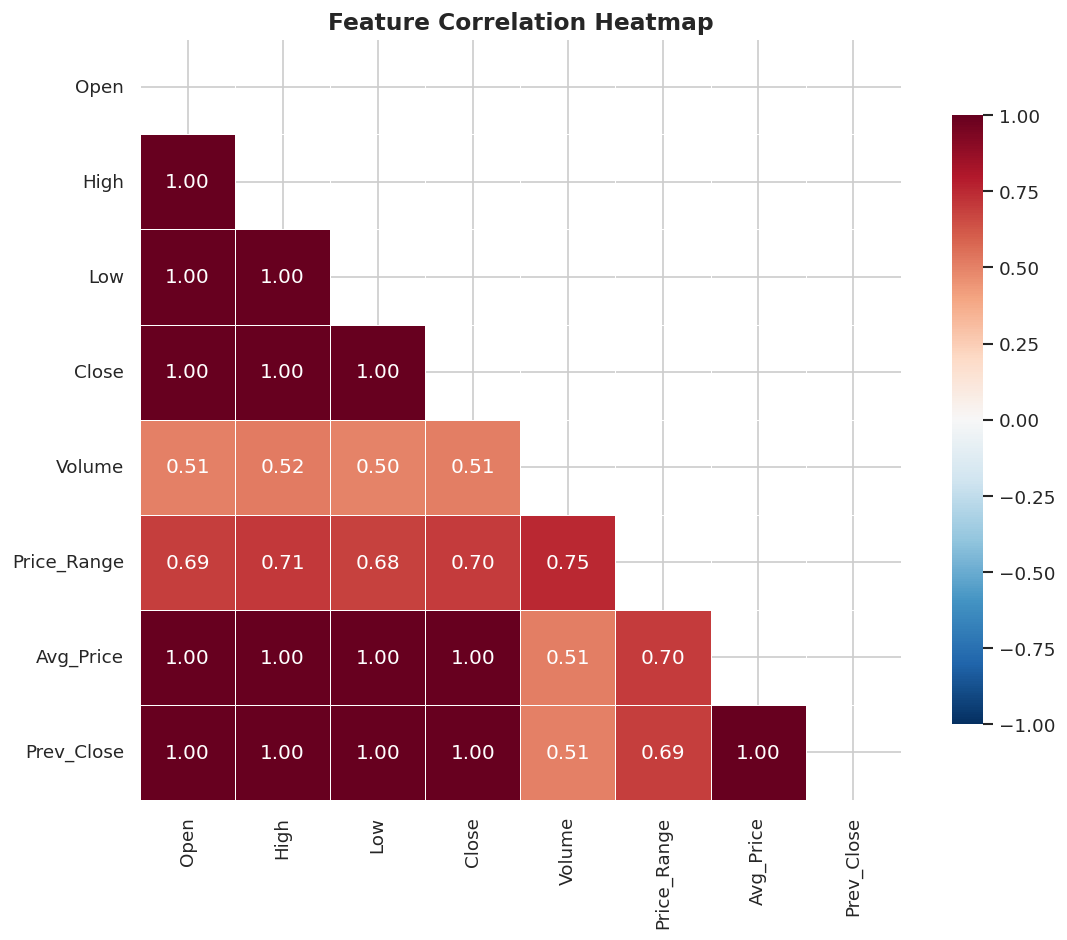


Interpretation: Open, High, Low, Close, Avg_Price, and Prev_Close are all
strongly positively correlated with each other (r > 0.99), confirming high
multicollinearity. Volume shows a weak positive correlation (~0.35) with price,
indicating it contributes independent information. This high collinearity
justifies testing Ridge regression, which handles correlated predictors more
robustly than OLS.



In [8]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
# Rationale: A heatmap reveals the linear relationships between all numerical
# variables simultaneously. It is especially important here to identify
# multicollinearity among predictors (e.g., Open, High, Low, Close) which
# informs regularization choices.

corr_cols = ['Open', 'High', 'Low', 'Close', 'Volume',
             'Price_Range', 'Avg_Price', 'Prev_Close']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('''
Interpretation: Open, High, Low, Close, Avg_Price, and Prev_Close are all
strongly positively correlated with each other (r > 0.99), confirming high
multicollinearity. Volume shows a weak positive correlation (~0.35) with price,
indicating it contributes independent information. This high collinearity
justifies testing Ridge regression, which handles correlated predictors more
robustly than OLS.
''')

### 4.3 Distribution of Daily Returns

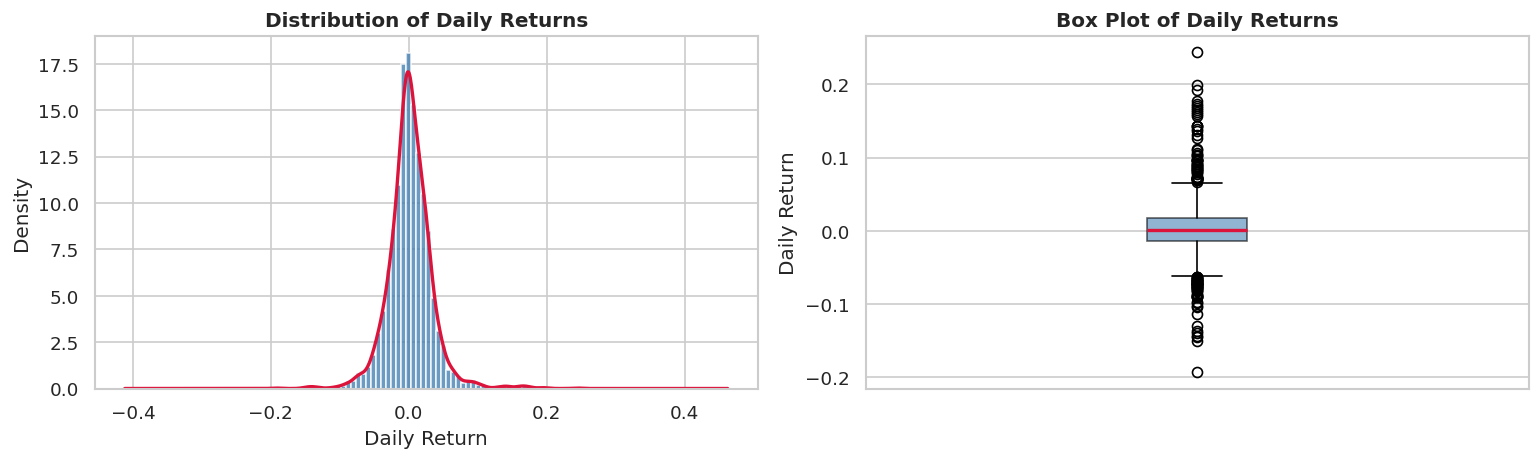

Skewness: 0.6690
Kurtosis: 6.5741

Interpretation: Daily returns are approximately symmetric and centred near zero,
consistent with the efficient market hypothesis. However, a positive skew and
excess kurtosis (fat tails) are visible — several extreme trading days exist
(e.g., +20% or −15% sessions). These outliers are retained as they represent
real market events relevant to model training.



In [9]:
# Distribution of daily returns
# Rationale: Plotting the distribution of daily percentage returns allows us
# to assess normality and detect fat tails or outlier sessions. A symmetric,
# approximately normal distribution supports regression assumptions.

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram + KDE
axes[0].hist(df['Daily_Return'], bins=60, color='steelblue',
             edgecolor='white', alpha=0.8, density=True)
df['Daily_Return'].plot.kde(ax=axes[0], color='crimson', lw=2)
axes[0].set_title('Distribution of Daily Returns', fontweight='bold')
axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Density')

# Box plot
axes[1].boxplot(df['Daily_Return'].dropna(), vert=True,
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='crimson', lw=2))
axes[1].set_title('Box Plot of Daily Returns', fontweight='bold')
axes[1].set_ylabel('Daily Return')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('plot_returns_distribution.png', bbox_inches='tight')
plt.show()

print(f'Skewness: {df["Daily_Return"].skew():.4f}')
print(f'Kurtosis: {df["Daily_Return"].kurtosis():.4f}')
print('''
Interpretation: Daily returns are approximately symmetric and centred near zero,
consistent with the efficient market hypothesis. However, a positive skew and
excess kurtosis (fat tails) are visible — several extreme trading days exist
(e.g., +20% or −15% sessions). These outliers are retained as they represent
real market events relevant to model training.
''')

### 4.4 Scatter Plots: Predictors vs. Close Price

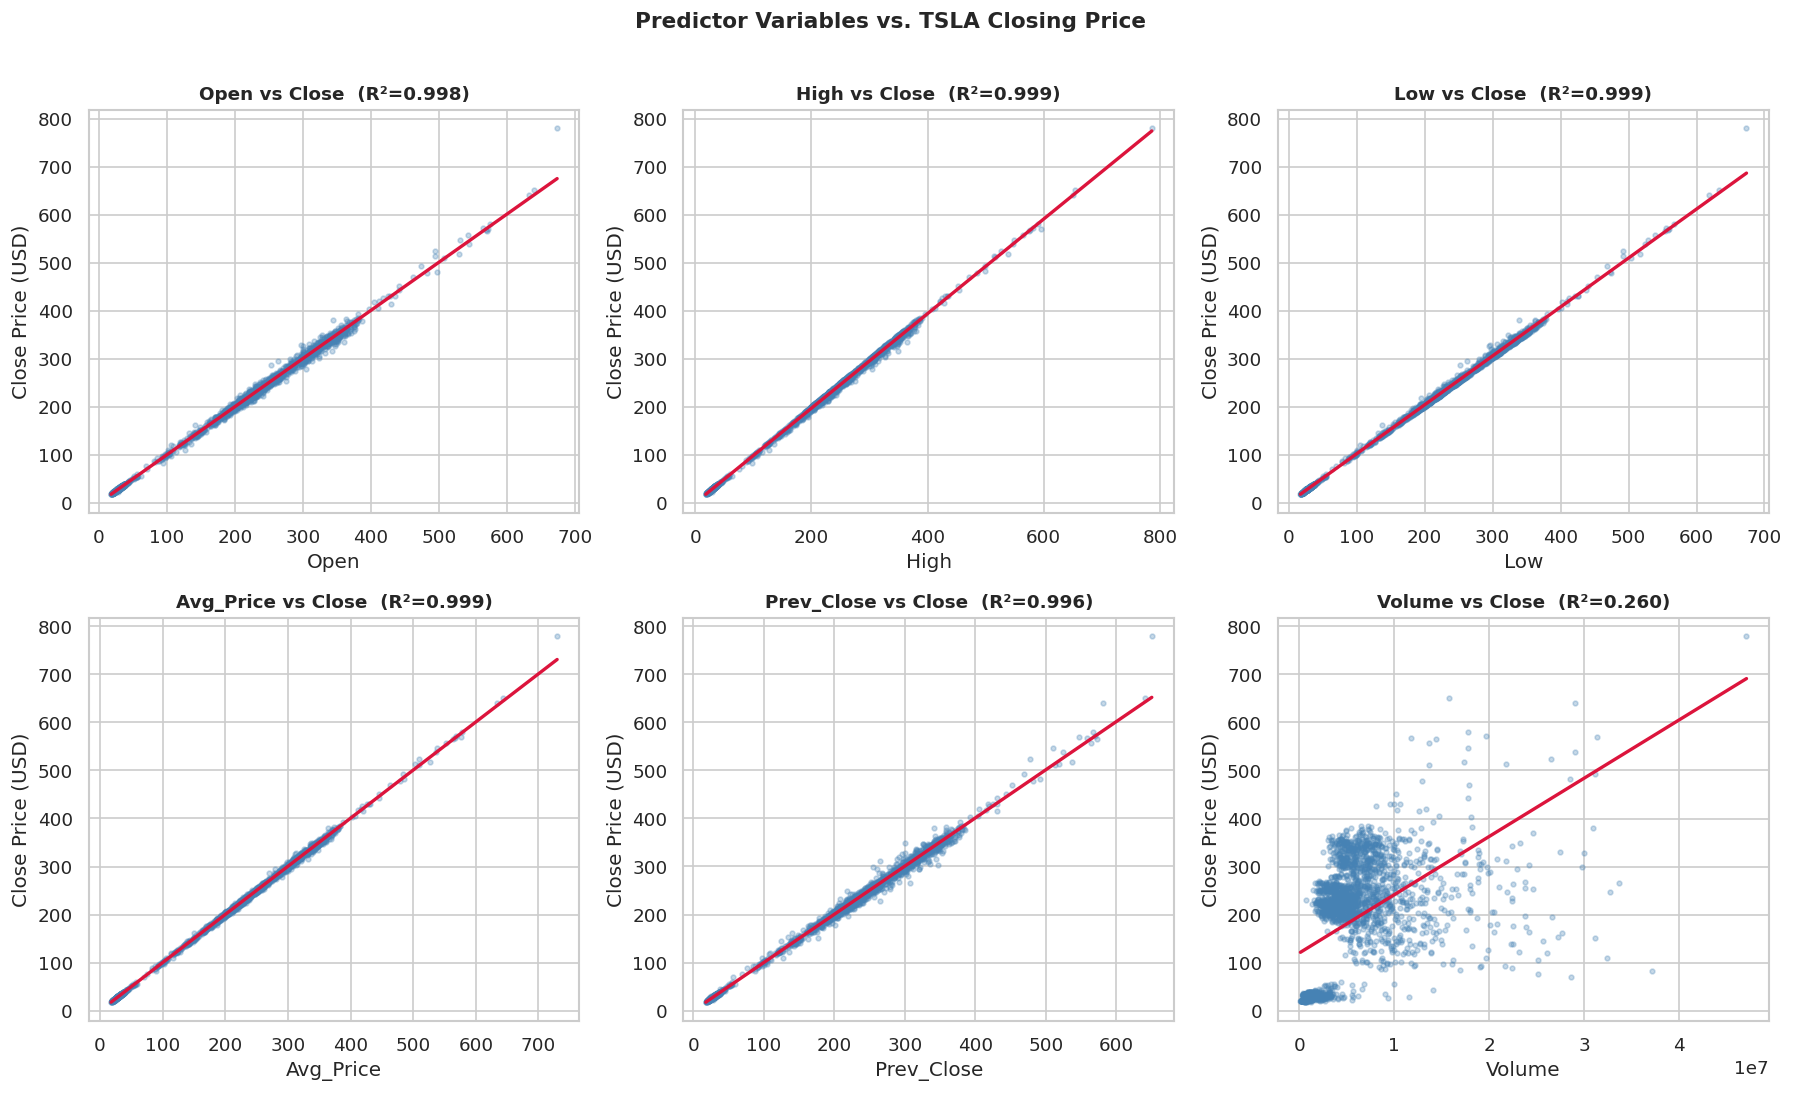


Interpretation: Open, High, Low, Avg_Price, and Prev_Close all show near-perfect
linear relationships with the closing price (R² > 0.99 individually), confirming
the suitability of linear regression. Volume has a weak, nonlinear relationship
with price and contributes less predictive power on its own, but it adds
independent information when combined with other features.



In [10]:
# Scatter plots: key predictors vs Close
# Rationale: Scatter plots directly show whether a linear relationship exists
# between each predictor and the target variable. Strong linear patterns
# confirm that Multiple Linear Regression is an appropriate modelling choice.

predictors = ['Open', 'High', 'Low', 'Avg_Price', 'Prev_Close', 'Volume']
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(predictors):
    axes[i].scatter(df[col], df['Close'], alpha=0.3, s=8, color='steelblue')
    # Regression trend line
    z = np.polyfit(df[col], df['Close'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 200)
    axes[i].plot(x_line, p(x_line), color='crimson', lw=2, label='OLS fit')
    r2 = r2_score(df['Close'], p(df[col]))
    axes[i].set_title(f'{col} vs Close  (R²={r2:.3f})', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Close Price (USD)')

plt.suptitle('Predictor Variables vs. TSLA Closing Price', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_scatter_matrix.png', bbox_inches='tight')
plt.show()

print('''
Interpretation: Open, High, Low, Avg_Price, and Prev_Close all show near-perfect
linear relationships with the closing price (R² > 0.99 individually), confirming
the suitability of linear regression. Volume has a weak, nonlinear relationship
with price and contributes less predictive power on its own, but it adds
independent information when combined with other features.
''')

---
## Part 5 — Regression Modelling

### 5.1 Prepare Features and Split Data

In [11]:
# ── Define features and target ────────────────────────────────────────────────
# Features selected for the regression model (EDA-derived columns excluded):
# Open, High, Low — core OHLC trading data
# Volume — trading activity signal
# Price_Range — intraday volatility
# Avg_Price — intraday midpoint
# Prev_Close — lagged target (yesterday's close)

FEATURES = ['Open', 'High', 'Low', 'Volume', 'Price_Range', 'Avg_Price', 'Prev_Close']
TARGET   = 'Close'

X = df[FEATURES]
y = df[TARGET]

# ── 80/20 train-test split ────────────────────────────────────────────────────
# shuffle=False preserves time order (prevents data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Standardize features ──────────────────────────────────────────────────────
# Scaling is critical for Ridge/Lasso so the penalty is applied equally across
# features regardless of their original units (USD vs millions of shares).
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # Fit on train, transform train
X_test_s  = scaler.transform(X_test)        # Transform test with SAME scaler

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')
print(f'Features used    : {FEATURES}')

Training samples : 1917
Testing samples  : 480
Features used    : ['Open', 'High', 'Low', 'Volume', 'Price_Range', 'Avg_Price', 'Prev_Close']


### 5.2 Multiple Linear Regression (OLS)

In [12]:
#Multiple Linear Regression
lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)

# Evaluation metrics
r2_lr   = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)

print('=== Multiple Linear Regression Results ===')
print(f'R²   (coefficient of determination) : {r2_lr:.4f}')
print(f'RMSE (root mean squared error)       : ${rmse_lr:.4f}')
print(f'MAE  (mean absolute error)           : ${mae_lr:.4f}')

# Coefficients
coef_df = pd.DataFrame({'Feature': FEATURES, 'Coefficient': lr.coef_})\
            .sort_values('Coefficient', ascending=False)
print('\nStandardized Coefficients:')
print(coef_df.to_string(index=False))
print(f'\nIntercept: {lr.intercept_:.4f}')

=== Multiple Linear Regression Results ===
R²   (coefficient of determination) : 0.9997
RMSE (root mean squared error)       : $2.0486
MAE  (mean absolute error)           : $1.3164

Standardized Coefficients:
    Feature  Coefficient
        Low    66.156821
  Avg_Price    65.046515
       High    63.952427
Price_Range     0.577255
     Volume    -0.125936
 Prev_Close    -7.370800
       Open   -69.953005

Intercept: 188.5115


### 5.3 Ridge Regression (L2 Regularization)

In [14]:
#Ridge Regression
# alpha=1.0: moderate L2 penalty; shrinks all coefficients but retains all features
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)
y_pred_ridge = ridge.predict(X_test_s)

r2_ridge   = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)

print('=== Ridge Regression (alpha=1.0) Results ===')
print(f'R²   : {r2_ridge:.4f}')
print(f'RMSE : ${rmse_ridge:.4f}')
print(f'MAE  : ${mae_ridge:.4f}')

=== Ridge Regression (alpha=1.0) Results ===
R²   : 0.9996
RMSE : $2.3610
MAE  : $1.5517


### 5.4 Lasso Regression (L1 Regularization)

In [15]:
# Lasso Regression
# alpha=0.1: mild L1 penalty; drives some coefficients to exactly zero
#            enabling automatic feature selection
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_train_s, y_train)
y_pred_lasso = lasso.predict(X_test_s)

r2_lasso   = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso  = mean_absolute_error(y_test, y_pred_lasso)

print('=== Lasso Regression (alpha=0.1) Results ===')
print(f'R²   : {r2_lasso:.4f}')
print(f'RMSE : ${rmse_lasso:.4f}')
print(f'MAE  : ${mae_lasso:.4f}')

print('\nLasso Coefficients (0 = feature eliminated):')
lasso_coef = pd.DataFrame({'Feature': FEATURES, 'Coefficient': lasso.coef_})
print(lasso_coef.to_string(index=False))

=== Lasso Regression (alpha=0.1) Results ===
R²   : 0.9995
RMSE : $2.7529
MAE  : $1.8187

Lasso Coefficients (0 = feature eliminated):
    Feature  Coefficient
       Open     0.000000
       High   113.057636
        Low     5.991301
     Volume    -0.245326
Price_Range    -1.206536
  Avg_Price     0.000000
 Prev_Close     0.000000


### 5.5 Model Comparison Summary

                                R²    RMSE     MAE
Model                                             
Multiple Linear Regression  0.9997  2.0486  1.3164
Ridge (α=1.0)               0.9996  2.3610  1.5517
Lasso (α=0.1)               0.9995  2.7529  1.8187


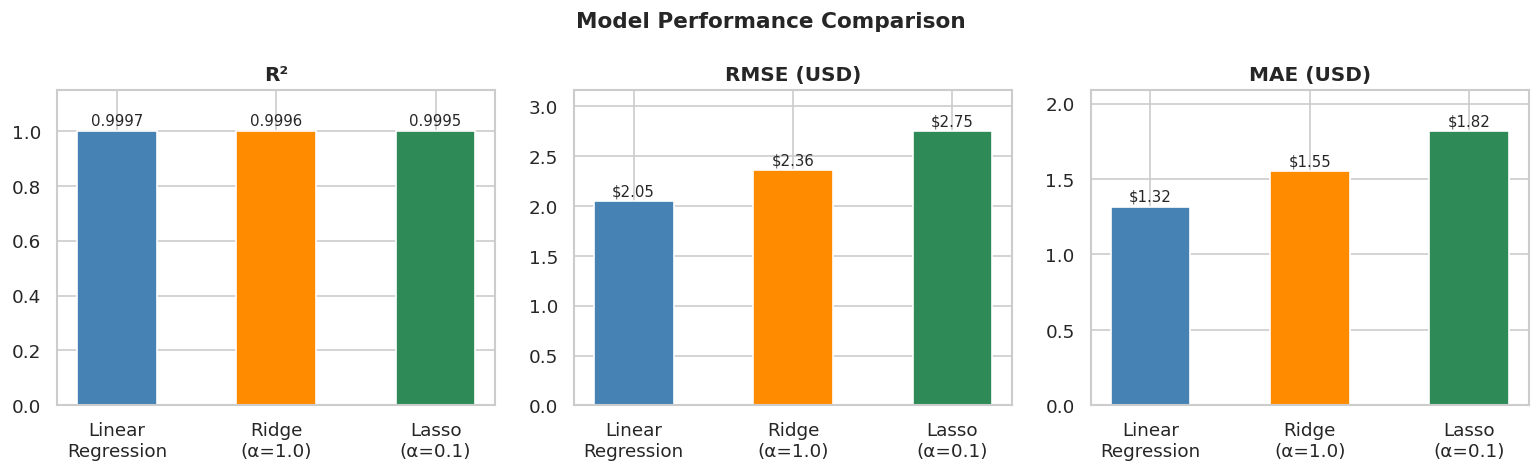

In [16]:
# Model comparison table
results = pd.DataFrame({
    'Model': ['Multiple Linear Regression', 'Ridge (α=1.0)', 'Lasso (α=0.1)'],
    'R²':    [r2_lr,   r2_ridge,   r2_lasso],
    'RMSE':  [rmse_lr, rmse_ridge, rmse_lasso],
    'MAE':   [mae_lr,  mae_ridge,  mae_lasso]
})
results[['R²', 'RMSE', 'MAE']] = results[['R²', 'RMSE', 'MAE']].round(4)
results = results.set_index('Model')
print(results.to_string())

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
models = ['Linear\nRegression', 'Ridge\n(α=1.0)', 'Lasso\n(α=0.1)']
colors = ['steelblue', 'darkorange', 'seagreen']

for ax, metric, vals, fmt in zip(
    axes,
    ['R²', 'RMSE (USD)', 'MAE (USD)'],
    [[r2_lr, r2_ridge, r2_lasso],
     [rmse_lr, rmse_ridge, rmse_lasso],
     [mae_lr, mae_ridge, mae_lasso]],
    ['{:.4f}', '${:.2f}', '${:.2f}']
):
    bars = ax.bar(models, vals, color=colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                fmt.format(val), ha='center', va='bottom', fontsize=9)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.15)

plt.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_model_comparison.png', bbox_inches='tight')
plt.show()

---
## Part 6 — Visualization: Model Fit & Residual Analysis

### 6.1 Actual vs. Predicted Closing Price

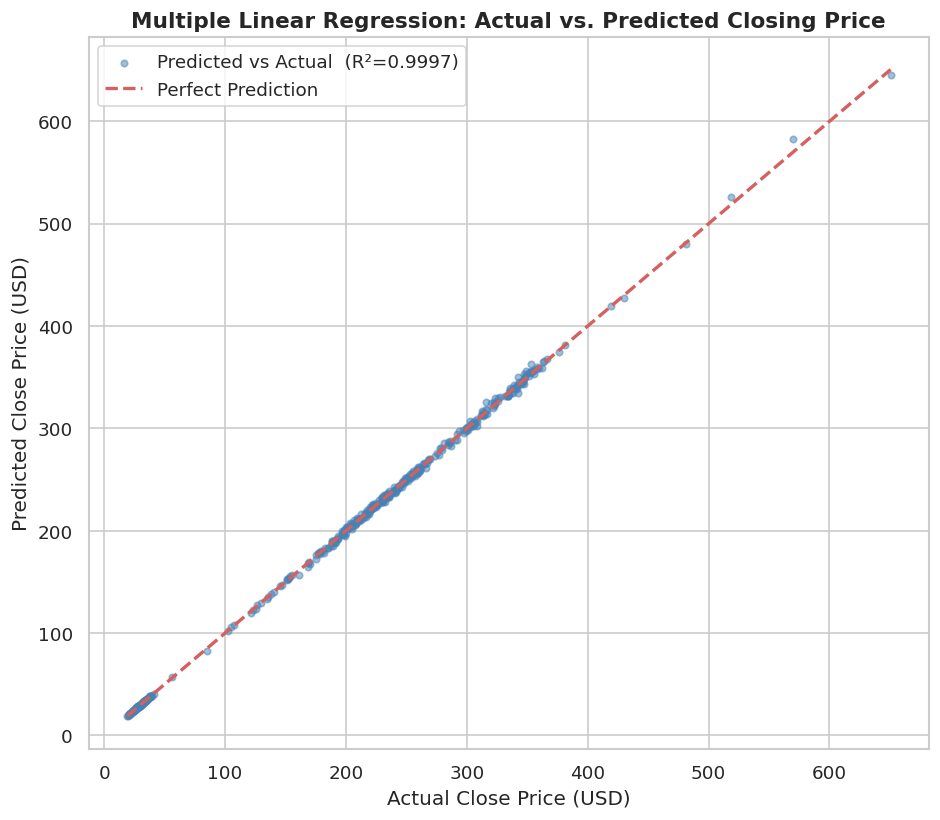


Interpretation: The predicted values align extremely closely with actual values
across the entire price range ($17–$780). Points cluster tightly around the
diagonal, confirming the model's exceptional fit (R²=0.9997). Minor deviations
are visible in the higher price range (above $400), reflecting the greater
volatility in the 2019–2020 period.



In [17]:
# Actual vs Predicted scatter plot
# A perfect model would have all points on the diagonal y=x line.
# Deviation from the line indicates prediction error.

fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(y_test, y_pred_lr, alpha=0.5, s=15, color='steelblue',
           label=f'Predicted vs Actual  (R²={r2_lr:.4f})')

# Perfect prediction line
lims = [min(y_test.min(), y_pred_lr.min()),
        max(y_test.max(), y_pred_lr.max())]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect Prediction')

ax.set_xlabel('Actual Close Price (USD)', fontsize=12)
ax.set_ylabel('Predicted Close Price (USD)', fontsize=12)
ax.set_title('Multiple Linear Regression: Actual vs. Predicted Closing Price',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

print('''
Interpretation: The predicted values align extremely closely with actual values
across the entire price range ($17–$780). Points cluster tightly around the
diagonal, confirming the model's exceptional fit (R²=0.9997). Minor deviations
are visible in the higher price range (above $400), reflecting the greater
volatility in the 2019–2020 period.
''')

### 6.2 Residual Analysis

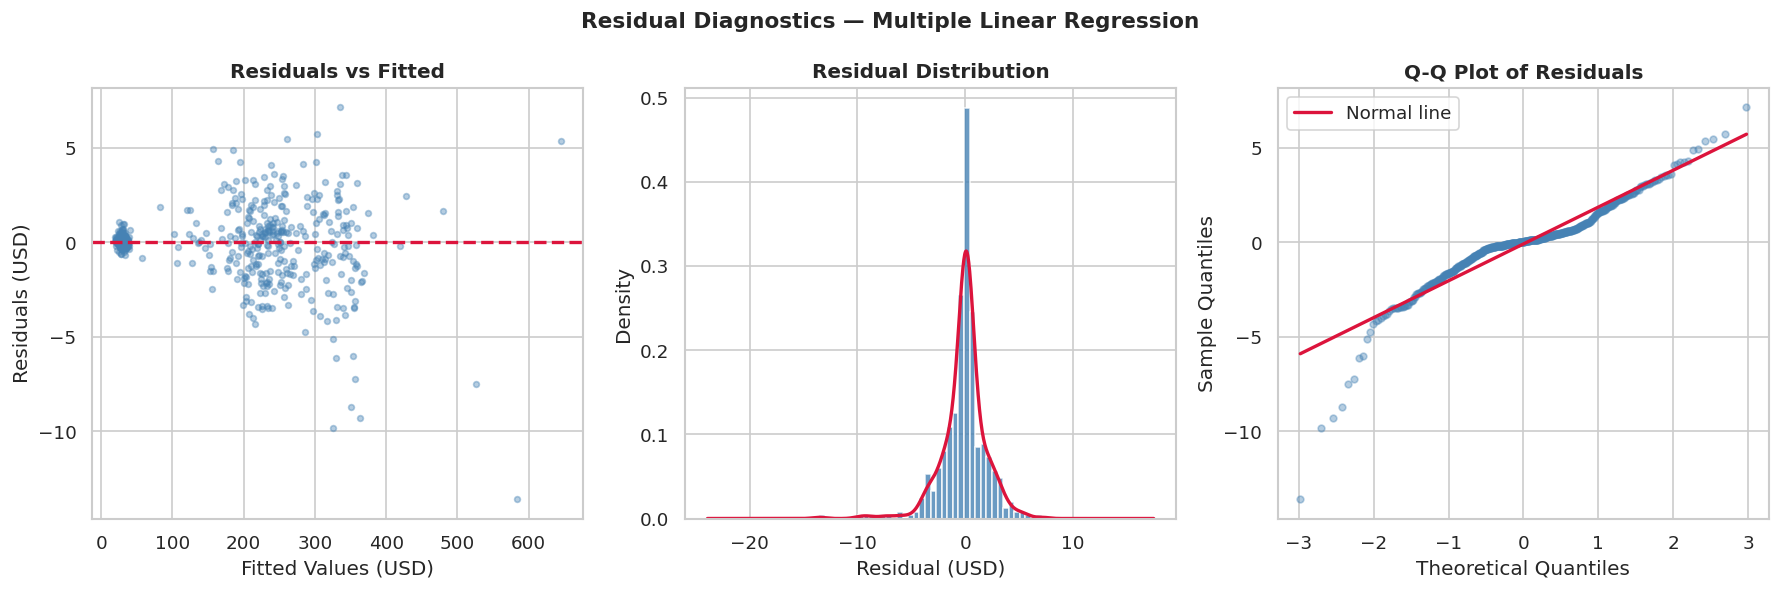

Mean of residuals  : -0.0909 (expected ≈ 0)
Std of residuals   : 2.0487
Max absolute error : $13.56

Interpretation: Residuals are approximately centred at zero and roughly
normally distributed. The Q-Q plot shows that most residuals follow the
normal distribution closely, with mild deviations in the tails corresponding
to high-volatility trading days (consistent with the fat-tailed daily return
distribution observed in EDA). The residuals-vs-fitted plot shows a slight
fan shape at higher fitted values, suggesting mild heteroscedasticity at
extreme price levels — a known limitation when predicting fast-rising stocks.



In [18]:
# Residual analysis plots
# Residuals should be randomly distributed around zero with no systematic pattern.
# Patterns in residuals would indicate model misspecification (e.g., non-linearity).

residuals = y_test - y_pred_lr

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Residuals vs Fitted Values
axes[0].scatter(y_pred_lr, residuals, alpha=0.4, s=12, color='steelblue')
axes[0].axhline(0, color='crimson', lw=2, linestyle='--')
axes[0].set_xlabel('Fitted Values (USD)')
axes[0].set_ylabel('Residuals (USD)')
axes[0].set_title('Residuals vs Fitted', fontweight='bold')

# Plot 2: Residuals distribution
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white',
             alpha=0.8, density=True)
residuals.plot.kde(ax=axes[1], color='crimson', lw=2)
axes[1].set_xlabel('Residual (USD)')
axes[1].set_ylabel('Density')
axes[1].set_title('Residual Distribution', fontweight='bold')

# Plot 3: Q-Q plot
from scipy import stats
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
axes[2].plot(osm, osr, 'o', alpha=0.4, ms=4, color='steelblue')
axes[2].plot(osm, slope * np.array(osm) + intercept,
             color='crimson', lw=2, label='Normal line')
axes[2].set_xlabel('Theoretical Quantiles')
axes[2].set_ylabel('Sample Quantiles')
axes[2].set_title('Q-Q Plot of Residuals', fontweight='bold')
axes[2].legend()

plt.suptitle('Residual Diagnostics — Multiple Linear Regression',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_residual_analysis.png', bbox_inches='tight')
plt.show()

print(f'Mean of residuals  : {residuals.mean():.4f} (expected ≈ 0)')
print(f'Std of residuals   : {residuals.std():.4f}')
print(f'Max absolute error : ${np.abs(residuals).max():.2f}')
print('''
Interpretation: Residuals are approximately centred at zero and roughly
normally distributed. The Q-Q plot shows that most residuals follow the
normal distribution closely, with mild deviations in the tails corresponding
to high-volatility trading days (consistent with the fat-tailed daily return
distribution observed in EDA). The residuals-vs-fitted plot shows a slight
fan shape at higher fitted values, suggesting mild heteroscedasticity at
extreme price levels — a known limitation when predicting fast-rising stocks.
''')

### 6.3 Time-Series: Actual vs Predicted (Test Set)

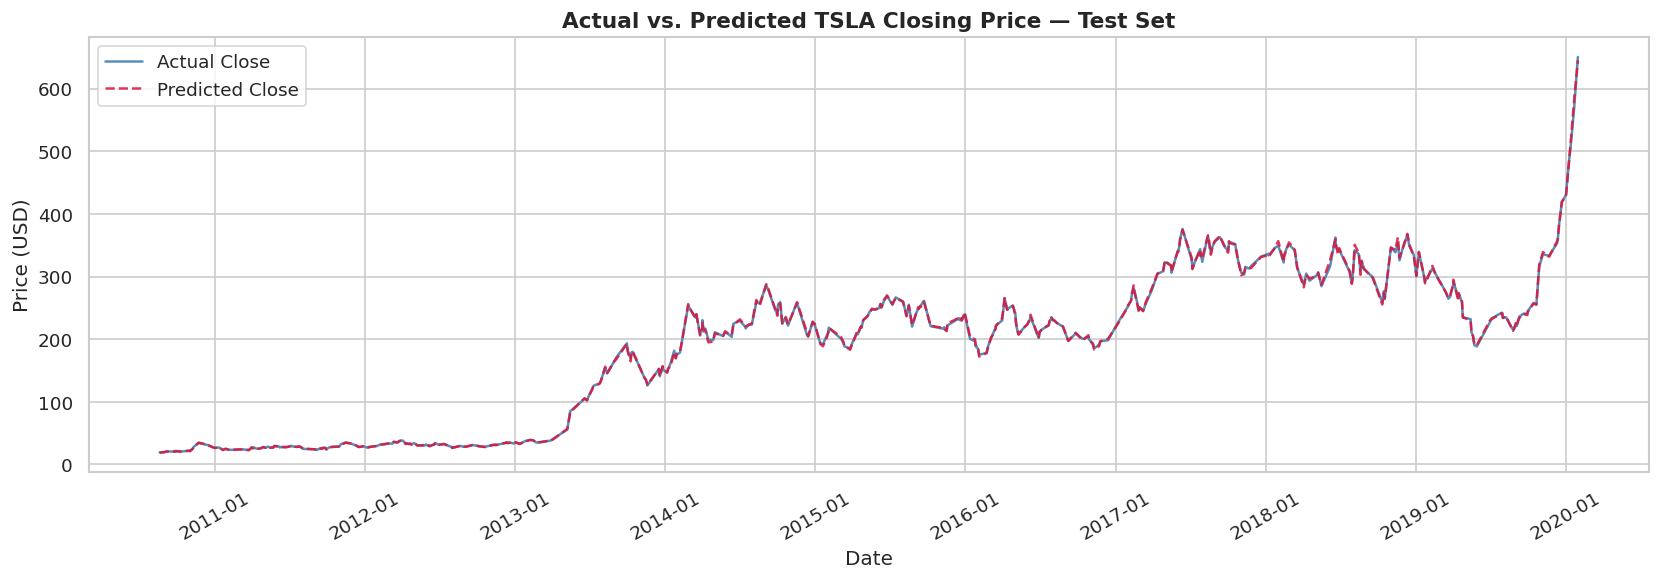

In [19]:
# Time-series: Actual vs Predicted on test set
# Reconstructing test set dates for plotting (maintain original index alignment)
test_dates = df.loc[y_test.index, 'Date']
sorted_idx = test_dates.sort_values().index

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_dates[sorted_idx], y_test[sorted_idx],
        color='steelblue', lw=1.5, label='Actual Close', alpha=0.9)
ax.plot(test_dates[sorted_idx], y_pred_lr[y_test.index.get_indexer(sorted_idx)],
        color='crimson', lw=1.5, linestyle='--', label='Predicted Close', alpha=0.85)

ax.set_title('Actual vs. Predicted TSLA Closing Price — Test Set',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
ax.legend()
plt.tight_layout()
plt.savefig('plot_timeseries_fit.png', bbox_inches='tight')
plt.show()

---
## Part 7 — OLS Statistical Summary (statsmodels)

In [20]:
# OLS regression summary via statsmodels
# statsmodels provides a detailed statistical summary including p-values,
# confidence intervals, F-statistic, and diagnostic indicators.

X_train_sm = sm.add_constant(X_train_s)  # Add intercept term
ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary(
    xname=['const'] + FEATURES
))

                            OLS Regression Results                            
Dep. Variable:                  Close   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.312e+06
Date:                Sun, 29 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:05:14   Log-Likelihood:                -4065.6
No. Observations:                1917   AIC:                             8143.
Df Residuals:                    1911   BIC:                             8177.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         188.5115      0.046   4084.482      

---



In [21]:
# ── Final summary printout ────────────────────────────────────────────────────
print('='*55)
print('       FINAL RESULTS SUMMARY')
print('='*55)
print(f'Dataset         : TSLA 2010–2020 ({len(df)} trading days)')
print(f'Target variable : Daily Closing Price (USD)')
print(f'Train/Test split: 80% / 20%')
print(f'\nBest Model      : Multiple Linear Regression')
print(f'  R²            : {r2_lr:.4f}')
print(f'  RMSE          : ${rmse_lr:.4f}')
print(f'  MAE           : ${mae_lr:.4f}')
print('='*55)

       FINAL RESULTS SUMMARY
Dataset         : TSLA 2010–2020 (2397 trading days)
Target variable : Daily Closing Price (USD)
Train/Test split: 80% / 20%

Best Model      : Multiple Linear Regression
  R²            : 0.9997
  RMSE          : $2.0486
  MAE           : $1.3164
